C:\Users\MSI\AppData\Local\Temp\ipykernel_9420\3020147654.py:68: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray.ravel(), 256, [0, 256], color='gray', alpha=0.7, label='Original')
C:\Users\MSI\AppData\Local\Temp\ipykernel_9420\3020147654.py:73: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray_eq.ravel(), 256, [0, 256], color='black', alpha=0.7, label='Equalized')
C:\Users\MSI\AppData\Local\Temp\ipykernel_9420\3020147654.py:79: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(y_original.ravel(), 256, [0, 256], color='orange', alpha=0.7, label='Original Y')
C:\Users\MSI\AppData\Local\Temp\ipy

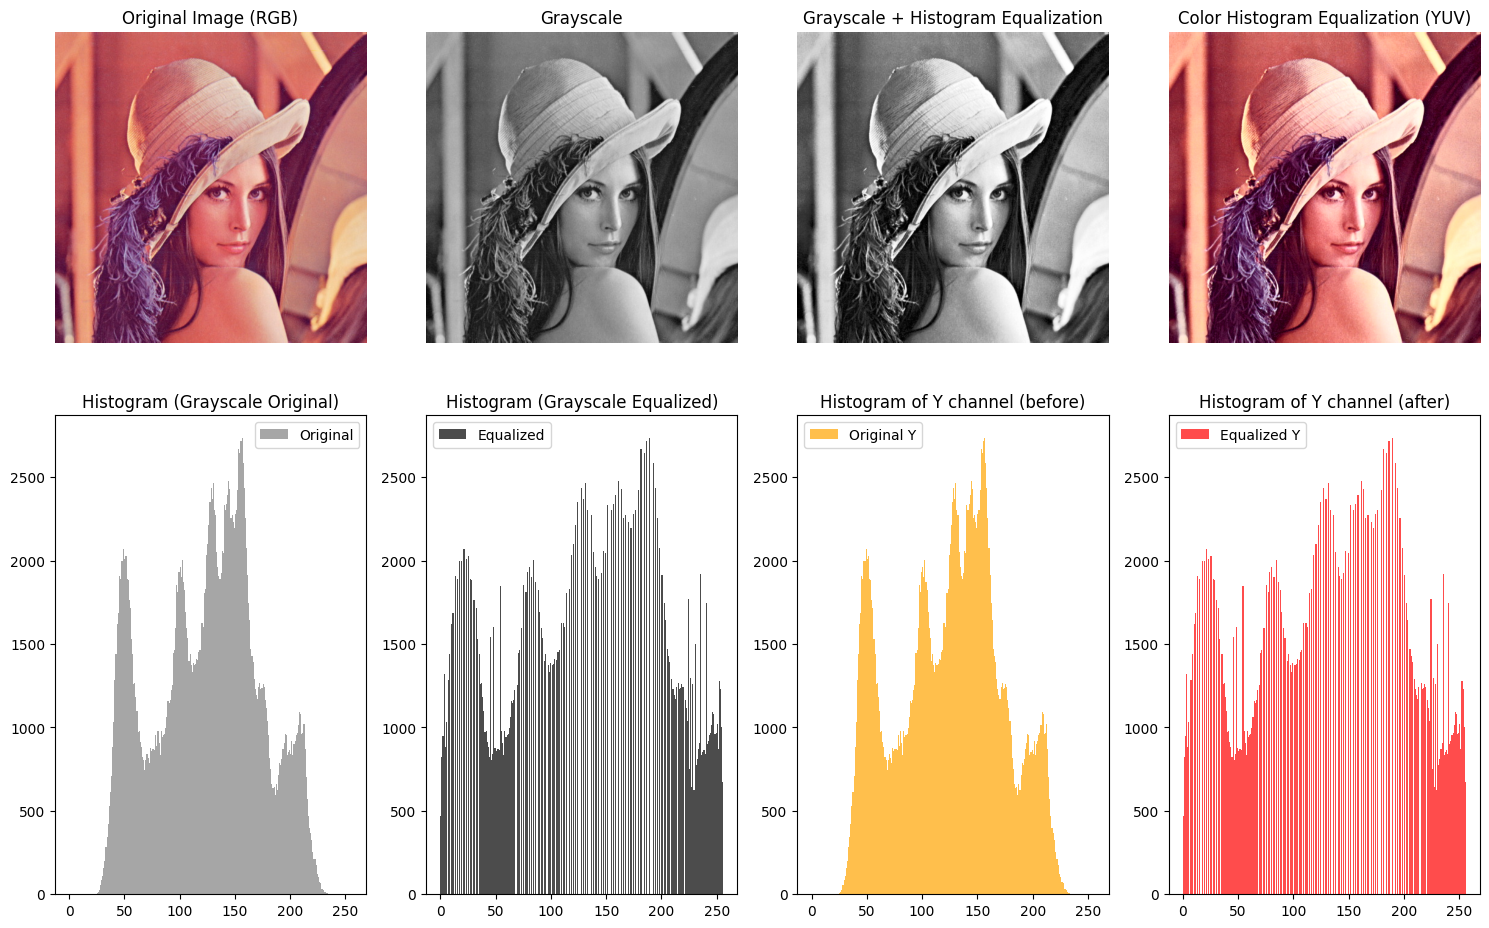

In [2]:
# Histogram Equalisation
import cv2
import numpy as np
import matplotlib.pyplot as plt


# =============================================
# Read the image
# =============================================
img = cv2.imread('lena.jpg')

# Convert from BGR (OpenCV default) to RGB for proper display with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =============================================
# 1. Grayscale Histogram Equalization
# =============================================
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply histogram equalization
img_gray_eq = cv2.equalizeHist(img_gray)

# =============================================
# 2. Color Histogram Equalization (using YUV color space)
# =============================================
# Convert to YUV
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Equalize only the Y (luminance) channel
y_original = img_yuv[:,:,0].copy()

img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])

# Convert back to BGR and then to RGB for display
img_color_eq = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

# =============================================
# Plotting results
# =============================================
plt.figure(figsize=(15, 10))

# Original RGB image
plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Original Image (RGB)')
plt.axis('off')

# Grayscale original
plt.subplot(2, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

# Grayscale equalized
plt.subplot(2, 4, 3)
plt.imshow(img_gray_eq, cmap='gray')
plt.title('Grayscale + Histogram Equalization')
plt.axis('off')

# Color equalized
plt.subplot(2, 4, 4)
plt.imshow(img_color_eq)
plt.title('Color Histogram Equalization (YUV)')
plt.axis('off')

# Histograms for grayscale
plt.subplot(2, 4, 5)
plt.hist(img_gray.ravel(), 256, [0, 256], color='gray', alpha=0.7, label='Original')
plt.title('Histogram (Grayscale Original)')
plt.legend()

plt.subplot(2, 4, 6)
plt.hist(img_gray_eq.ravel(), 256, [0, 256], color='black', alpha=0.7, label='Equalized')
plt.title('Histogram (Grayscale Equalized)')
plt.legend()

# Histograms for luminance channel (Y) in color image
plt.subplot(2, 4, 7)
plt.hist(y_original.ravel(), 256, [0, 256], color='orange', alpha=0.7, label='Original Y')
plt.title('Histogram of Y channel (before)')
plt.legend()

plt.subplot(2, 4, 8)
plt.hist(img_yuv[:,:,0].ravel(), 256, [0, 256], color='red', alpha=0.7, label='Equalized Y')
plt.title('Histogram of Y channel (after)')
plt.legend()

plt.tight_layout()
plt.show()
